# MEVO weather enrichment and statistical analysis

Sprint 3 prepares a reproducible, read-only weather-enrichment and statistical-analysis baseline for MEVO station-status data. The analytical grain is one system-hour, joined to one hourly weather observation for one representative point in the MEVO network.

This notebook is intentionally not a forecasting or production-feature notebook. It neither creates a target nor writes to S3, Glue, Athena, CURATED, or FEATURES.

## Scope and non-goals

The purpose is to assess whether a compact set of weather variables has useful incremental statistical association with observed system activity after simple temporal controls. It does not estimate causal effects and does not create an ML model, station-level weather model, weather ingestion pipeline, or production feature layer.

The baseline uses one representative weather point, calculated from the median latitude and longitude of active stations with valid coordinates. Per-station weather requests, regional clustering, station-sensitivity regressions, and weather forecasting are deliberately deferred.

## Methodological caveat: observed activity proxy

For cadence-valid station transitions only, the notebook uses:

- delta_bikes = current bikes_available - previous bikes_available
- activity_proxy = abs(delta_bikes)

This is an absolute station-level bike-count change, not a ride count, pickup count, return count, trip demand, or ground-truth demand. It can reflect user movements as well as rebalancing, service activity, and transport or other operator operations. Every result below is observational: associations are not causal claims.

## Imports, configuration, and dependencies

The repository declares only its production dependencies in pyproject.toml. As in notebooks 01–03, local analytical execution additionally requires boto3, awswrangler, pandas, numpy, matplotlib, requests, scipy, and IPython. Statsmodels is optional at import time but required for the statistical-regression sections; this notebook does not install packages or modify dependency files.

In [1]:
from __future__ import annotations

from datetime import timedelta
from typing import Iterable
from zoneinfo import ZoneInfo

try:
    import boto3
    import awswrangler as wr
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import requests
    from scipy import stats
    from IPython.display import display
except ImportError as exc:
    raise ImportError(
        'This notebook requires boto3, awswrangler, pandas, numpy, matplotlib, requests, scipy, and IPython. '
        'Install missing local analytical dependencies before the controlled final run; no installation is performed here.'
    ) from exc

try:
    import statsmodels.formula.api as smf
except ImportError:
    smf = None

AWS_REGION = 'eu-north-1'
ATHENA_DATABASE = 'mevo_analytics'
ATHENA_WORKGROUP = None
ATHENA_QUERY_RESULTS = None
FACT_TABLE = f'{ATHENA_DATABASE}.fact_station_status'
DIM_TABLE = f'{ATHENA_DATABASE}.dim_station'
LOCAL_TIMEZONE = 'Europe/Warsaw'
LOCAL_ZONE = ZoneInfo(LOCAL_TIMEZONE)

EXPECTED_CADENCE_MINUTES = 10
CADENCE_JITTER_TOLERANCE_MINUTES = 3
CADENCE_LOWER_MINUTES = EXPECTED_CADENCE_MINUTES - CADENCE_JITTER_TOLERANCE_MINUTES
CADENCE_UPPER_MINUTES = EXPECTED_CADENCE_MINUTES + CADENCE_JITTER_TOLERANCE_MINUTES

OPEN_METEO_ARCHIVE_URL = 'https://archive-api.open-meteo.com/v1/archive'
OPEN_METEO_MODEL = 'ecmwf_ifs'
CORE_WEATHER_VARIABLES = (
    'temperature_2m',
    'precipitation',
    'wind_speed_10m',
    'relative_humidity_2m',
    'pressure_msl',
)
EXPLORATORY_WEATHER_VARIABLES = (
    'wind_direction_10m',
    'sunshine_duration',
)
WEATHER_VARIABLES = CORE_WEATHER_VARIABLES + EXPLORATORY_WEATHER_VARIABLES
INSTANTANEOUS_WEATHER_VARIABLES = (
    'temperature_2m',
    'relative_humidity_2m',
    'pressure_msl',
    'wind_speed_10m',
    'wind_direction_10m',
)
PRECEDING_HOUR_WEATHER_VARIABLES = ('precipitation', 'sunshine_duration')

HTTP_TIMEOUT_SECONDS = 30
BOOTSTRAP_RESAMPLES = 2_000
BOOTSTRAP_RANDOM_SEED = 194586
HAC_MAXLAGS = 24
MIN_MODEL_OBSERVATIONS = 72
MIN_INTERACTION_GROUP_OBSERVATIONS = 24

session = boto3.Session(region_name=AWS_REGION)
print(
    f'Cadence-valid transition interval: {CADENCE_LOWER_MINUTES}–{CADENCE_UPPER_MINUTES} minutes. '
    f'Open-Meteo model is pinned to {OPEN_METEO_MODEL}; HAC maxlags={HAC_MAXLAGS}.'
)

Cadence-valid transition interval: 7–13 minutes. Open-Meteo model is pinned to ecmwf_ifs; HAC maxlags=24.


## Explicit analysis-window contract

The current execution is a preliminary integration and statistical baseline using the same historical MEVO period already analysed in saved Sprint 2 outputs. Results will be replaced by the final controlled approximately 30-day rerun.

The saved period summaries are not identical: notebook 02 covers 2026-08-12 00:52:12.353000 UTC through 2026-08-20 21:58:08.344000 UTC, while notebook 03 covers 2026-08-12 00:52:12.353000 UTC through 2026-08-23 21:58:08.250000 UTC. Notebook 02 applies an inclusive upper bound to its saved EDA range; notebook 03's saved period summary is a dynamic MIN/MAX inventory. Their common intersection is therefore used below.

This preliminary weather run uses the largest full-hour subwindow contained within the saved Sprint 2 analysis periods. It does not extend beyond the data used by notebooks 02–03. The subwindow is [2026-08-12 01:00:00 UTC, 2026-08-20 21:00:00 UTC).

For the later final run, values of ANALYSIS_START_UTC and ANALYSIS_END_UTC must be copied or confirmed from the controlled final rerun of Sprint 2 so that notebooks 01–04 analyse the same MEVO period. The contract is [ANALYSIS_START_UTC, ANALYSIS_END_UTC): start inclusive and end exclusive.

The final window is never inferred from the current minimum or maximum timestamp in Athena. Both bounds must be timezone-aware UTC timestamps aligned exactly to the beginning of an hour.

Before the final controlled rerun, freeze one explicit common UTC analysis window for notebooks 01–04. The current dynamic MIN/MAX behaviour of Sprint 2 notebooks must not lead to different periods if new CLEANED partitions arrive between executions.

In [2]:
ANALYSIS_MODE = 'preliminary'
# This flag permits the preliminary external-data validation run; it is not final sign-off.
FINAL_ANALYSIS_ENABLED = True
ANALYSIS_START_UTC = pd.Timestamp('2026-08-12 01:00:00', tz='UTC')
ANALYSIS_END_UTC = pd.Timestamp('2026-08-20 21:00:00', tz='UTC')


def validate_analysis_window(
    analysis_start_utc: object,
    analysis_end_utc: object,
) -> tuple[pd.Timestamp, pd.Timestamp]:
    '''Validate the explicit UTC, hourly-aligned, half-open analysis window.'''
    if analysis_start_utc is None or analysis_end_utc is None:
        raise ValueError(
            'Set both ANALYSIS_START_UTC and ANALYSIS_END_UTC from the saved preliminary period or a controlled final Sprint 2 rerun. '
            'The notebook will not infer a window from currently available data.'
        )

    parsed: list[pd.Timestamp] = []
    for label, value in (
        ('ANALYSIS_START_UTC', analysis_start_utc),
        ('ANALYSIS_END_UTC', analysis_end_utc),
    ):
        timestamp = pd.Timestamp(value)
        if timestamp.tzinfo is None:
            raise ValueError(f'{label} must be timezone-aware UTC, not a naive timestamp.')
        if str(timestamp.tz) != 'UTC':
            raise ValueError(f'{label} must use the UTC timezone explicitly; received {timestamp.tz}.')
        if any((timestamp.minute, timestamp.second, timestamp.microsecond, timestamp.nanosecond)):
            raise ValueError(f'{label} must be aligned exactly to the beginning of an hour.')
        parsed.append(timestamp)

    start_utc, end_utc = parsed
    if start_utc >= end_utc:
        raise ValueError('ANALYSIS_START_UTC must be earlier than ANALYSIS_END_UTC.')
    return start_utc, end_utc


def require_external_analysis_enabled() -> tuple[pd.Timestamp, pd.Timestamp]:
    '''Guard every external data load behind the explicit preliminary/final execution contract.'''
    if ANALYSIS_MODE not in {'preliminary', 'final'}:
        raise ValueError("ANALYSIS_MODE must be 'preliminary' or 'final'.")
    if FINAL_ANALYSIS_ENABLED is not True:
        raise RuntimeError(
            'External analysis execution is disabled. Confirm the shared Sprint 2 window, set both UTC bounds, '
            'and set FINAL_ANALYSIS_ENABLED = True before executing Athena or Open-Meteo loads.'
        )
    return validate_analysis_window(ANALYSIS_START_UTC, ANALYSIS_END_UTC)


def athena_timestamp_literal(value: object) -> str:
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None or str(timestamp.tz) != 'UTC':
        raise ValueError('Athena timestamp literals must be created from timezone-aware UTC timestamps.')
    timestamp = timestamp.tz_convert('UTC')
    return 'TIMESTAMP ' + chr(39) + timestamp.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3] + chr(39)

## AWS and Athena read-only setup

Athena performs the status-table scan, station-level lag, cadence validation, and hourly aggregation. Pandas receives only compact system-hour and coordinate-summary results. The helper below executes SELECT or CTE-only SQL with ctas_approach disabled; it never creates tables, unloads data, or publishes data.

In [3]:
def run_athena_query(sql: str) -> pd.DataFrame:
    '''Run one compact, read-only Athena query.'''
    query_upper = sql.lstrip().upper()
    forbidden = (
        'INSERT INTO', 'CREATE TABLE', 'CREATE VIEW', 'UNLOAD', 'DELETE ', 'UPDATE ',
        'DROP ', 'ALTER ', 'TRUNCATE ', 'MERGE ', 'MSCK ', 'GRANT ', 'REVOKE ',
    )
    if not (query_upper.startswith('SELECT') or query_upper.startswith('WITH')):
        raise ValueError('Only SELECT or CTE Athena SQL is permitted in this notebook.')
    if any(phrase in query_upper for phrase in forbidden):
        raise ValueError('Only read-only SELECT or CTE Athena SQL is permitted in this notebook.')

    query_kwargs = {
        'database': ATHENA_DATABASE,
        'boto3_session': session,
        'ctas_approach': False,
    }
    if ATHENA_WORKGROUP is not None:
        query_kwargs['workgroup'] = ATHENA_WORKGROUP
    if ATHENA_QUERY_RESULTS is not None:
        query_kwargs['s3_output'] = ATHENA_QUERY_RESULTS
    return wr.athena.read_sql_query(sql, **query_kwargs)

## System-hour MEVO aggregation

The main grain is SYSTEM-HOUR. A weather observation is therefore never duplicated across six ten-minute snapshots and treated as six independent weather observations. The core output is hour_ts_utc, activity_proxy_sum, valid_transition_count, activity_rate, and valid_transition_station_count. activity_proxy_sum is the total observed absolute station-level bike-count change in the hour; activity_rate = activity_proxy_sum / valid_transition_count is the mean proxy activity per valid transition observation.

The SQL reuses notebook 03 semantics exactly: within each station, a transition is cadence-valid only when the current and previous snapshots are 7–13 minutes apart. A minimal 13-minute warm-up is read before the window so the first in-window current observation can use a preceding snapshot for LAG. Only current observations in the shared half-open analysis window contribute to support and system-hour aggregation; warm-up rows never contribute to the result.

In [4]:
def build_system_hour_sql(start_utc: object, end_utc: object) -> str:
    '''Build compact system-hour activity SQL using notebook 03 cadence semantics.'''
    start_utc, end_utc = validate_analysis_window(start_utc, end_utc)
    warmup_start_utc = start_utc - pd.Timedelta(minutes=CADENCE_UPPER_MINUTES)
    start_literal = athena_timestamp_literal(start_utc)
    warmup_start_literal = athena_timestamp_literal(warmup_start_utc)
    end_literal = athena_timestamp_literal(end_utc)
    return f'''
WITH warmup_station_status AS (
    SELECT
        f.snapshot_ts,
        f.station_id,
        f.bikes_available
    FROM {FACT_TABLE} f
    WHERE f.snapshot_ts >= {warmup_start_literal}
      AND f.snapshot_ts < {end_literal}
),
analysis_window_station_status AS (
    SELECT snapshot_ts, station_id, bikes_available
    FROM warmup_station_status
    WHERE snapshot_ts >= {start_literal}
      AND snapshot_ts < {end_literal}
),
ordered_station_status AS (
    SELECT
        snapshot_ts,
        station_id,
        bikes_available,
        LAG(snapshot_ts) OVER station_window AS prev_snapshot_ts,
        LAG(bikes_available) OVER station_window AS prev_bikes
    FROM warmup_station_status
    WINDOW station_window AS (PARTITION BY station_id ORDER BY snapshot_ts)
),
cadence_valid_transitions AS (
    SELECT
        snapshot_ts,
        station_id,
        CASE
            WHEN prev_snapshot_ts IS NOT NULL
             AND date_diff('second', prev_snapshot_ts, snapshot_ts) / 60.0
                 BETWEEN {CADENCE_LOWER_MINUTES} AND {CADENCE_UPPER_MINUTES}
            THEN bikes_available - prev_bikes
        END AS delta_bikes
    FROM ordered_station_status
),
analysis_window_transitions AS (
    SELECT snapshot_ts, station_id, delta_bikes
    FROM cadence_valid_transitions
    WHERE snapshot_ts >= {start_literal}
      AND snapshot_ts < {end_literal}
),
hourly_snapshot_support AS (
    SELECT
        date_trunc('hour', snapshot_ts) AS hour_ts_utc,
        COUNT(DISTINCT station_id) AS reporting_station_count
    FROM analysis_window_station_status
    GROUP BY 1
),
hourly_activity AS (
    SELECT
        date_trunc('hour', snapshot_ts) AS hour_ts_utc,
        COALESCE(SUM(CAST(ABS(delta_bikes) AS DOUBLE)), 0.0) AS activity_proxy_sum,
        COUNT(delta_bikes) AS valid_transition_count,
        COUNT(DISTINCT CASE WHEN delta_bikes IS NOT NULL THEN station_id END) AS valid_transition_station_count
    FROM analysis_window_transitions
    GROUP BY 1
)
SELECT
    s.hour_ts_utc,
    COALESCE(a.activity_proxy_sum, 0.0) AS activity_proxy_sum,
    COALESCE(a.valid_transition_count, 0) AS valid_transition_count,
    CASE
        WHEN COALESCE(a.valid_transition_count, 0) > 0
        THEN a.activity_proxy_sum / CAST(a.valid_transition_count AS DOUBLE)
    END AS activity_rate,
    COALESCE(a.valid_transition_station_count, 0) AS valid_transition_station_count,
    s.reporting_station_count
FROM hourly_snapshot_support s
LEFT JOIN hourly_activity a ON s.hour_ts_utc = a.hour_ts_utc
ORDER BY s.hour_ts_utc
'''


def load_system_hour_mevo(start_utc: object, end_utc: object) -> pd.DataFrame:
    '''Execute the guarded compact system-hour Athena query.'''
    require_external_analysis_enabled()
    frame = run_athena_query(build_system_hour_sql(start_utc, end_utc)).copy()
    frame['hour_ts_utc'] = pd.to_datetime(frame['hour_ts_utc'], utc=True)
    for column in frame.columns:
        if column != 'hour_ts_utc':
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
    return frame.sort_values('hour_ts_utc').reset_index(drop=True)

In [5]:
def _dq_status(condition: bool, fail: bool = False) -> str:
    if condition:
        return 'PASS'
    return 'FAIL' if fail else 'WARN'


def validate_mevo_hourly(
    mevo_hourly: pd.DataFrame,
    start_utc: object,
    end_utc: object,
) -> pd.DataFrame:
    '''Return compact DQ evidence for the system-hour result without changing it.'''
    start_utc, end_utc = validate_analysis_window(start_utc, end_utc)
    required = {
        'hour_ts_utc', 'activity_proxy_sum', 'valid_transition_count',
        'activity_rate', 'valid_transition_station_count',
    }
    missing_columns = sorted(required - set(mevo_hourly.columns))
    if missing_columns:
        raise ValueError(f'MEVO system-hour result is missing columns: {missing_columns}')

    hours = pd.to_datetime(mevo_hourly['hour_ts_utc'], utc=True)
    expected_hours = pd.date_range(start_utc, end_utc, freq='h', inclusive='left')
    missing_hours = expected_hours.difference(pd.DatetimeIndex(hours))
    duplicates = int(hours.duplicated().sum())
    invalid_rates = int((
        mevo_hourly['valid_transition_count'].gt(0)
        & ~np.isclose(
            mevo_hourly['activity_rate'],
            mevo_hourly['activity_proxy_sum'] / mevo_hourly['valid_transition_count'],
            equal_nan=True,
        )
    ).sum())
    return pd.DataFrame([
        {'metric': 'expected_hour_count', 'value': len(expected_hours), 'status': 'PASS', 'note': 'Half-open shared analysis window.'},
        {'metric': 'mevo_hour_count', 'value': len(mevo_hourly), 'status': _dq_status(len(mevo_hourly) == len(expected_hours)), 'note': 'One row per observed system hour.'},
        {'metric': 'duplicate_hour_keys', 'value': duplicates, 'status': _dq_status(duplicates == 0, fail=True), 'note': 'hour_ts_utc must be unique.'},
        {'metric': 'sorted_hour_keys', 'value': bool(hours.is_monotonic_increasing), 'status': _dq_status(bool(hours.is_monotonic_increasing)), 'note': 'System-hour rows should be chronological.'},
        {'metric': 'missing_expected_hours', 'value': len(missing_hours), 'status': _dq_status(len(missing_hours) == 0), 'note': 'Missing hours are retained as a DQ finding.'},
        {'metric': 'nonpositive_transition_hours', 'value': int(mevo_hourly['valid_transition_count'].le(0).sum()), 'status': _dq_status(int(mevo_hourly['valid_transition_count'].le(0).sum()) == 0), 'note': 'Zero-valid-transition hours are a support warning, not data corruption.'},
        {'metric': 'activity_rate_formula_mismatches', 'value': invalid_rates, 'status': _dq_status(invalid_rates == 0, fail=True), 'note': 'activity_rate must equal sum divided by valid transition count.'},
    ])

## Representative weather coordinates

The baseline requests weather for one point only. Athena identifies stations observed in the exact analysis window, joins their latest available dimension record, and calculates the median valid latitude and longitude. The resulting compact summary includes coordinate coverage, missing coordinate counts, and min/max bounds for review. Coordinates are not hard-coded.

In [6]:
def build_representative_coordinate_sql(start_utc: object, end_utc: object) -> str:
    start_utc, end_utc = validate_analysis_window(start_utc, end_utc)
    start_literal = athena_timestamp_literal(start_utc)
    end_literal = athena_timestamp_literal(end_utc)
    return f'''
WITH active_station_ids AS (
    SELECT DISTINCT station_id
    FROM {FACT_TABLE}
    WHERE snapshot_ts >= {start_literal}
      AND snapshot_ts < {end_literal}
),
latest_station_dimension AS (
    SELECT station_id, latitude, longitude
    FROM (
        SELECT
            d.station_id,
            d.latitude,
            d.longitude,
            ROW_NUMBER() OVER (PARTITION BY d.station_id ORDER BY d.snapshot_ts DESC) AS rn
        FROM {DIM_TABLE} d
        WHERE d.snapshot_ts < {end_literal}
    ) ranked_dimension
    WHERE rn = 1
),
active_station_coordinates AS (
    SELECT a.station_id, d.latitude, d.longitude
    FROM active_station_ids a
    LEFT JOIN latest_station_dimension d ON a.station_id = d.station_id
)
SELECT station_id, latitude, longitude
FROM active_station_coordinates
ORDER BY station_id
'''


def load_representative_coordinate_summary(start_utc: object, end_utc: object) -> pd.DataFrame:
    require_external_analysis_enabled()
    summary = run_athena_query(build_representative_coordinate_sql(start_utc, end_utc)).copy()
    for column in ('latitude', 'longitude'):
        summary[column] = pd.to_numeric(summary[column], errors='coerce')
    valid_mask = (
        summary['latitude'].between(-90, 90)
        & summary['longitude'].between(-180, 180)
    )
    missing_latitude_count = int(summary['latitude'].isna().sum())
    missing_longitude_count = int(summary['longitude'].isna().sum())
    invalid_coordinate_count = int((
        summary['latitude'].notna()
        & summary['longitude'].notna()
        & ~valid_mask
    ).sum())
    valid_coordinates = summary.loc[valid_mask, ['station_id', 'latitude', 'longitude']]
    if valid_coordinates.empty:
        raise RuntimeError('No valid active-station coordinates are available for the representative weather point.')
    coordinate_summary = pd.DataFrame([{
        'active_station_id_count': len(summary),
        'valid_coordinate_station_count': len(valid_coordinates),
        'missing_latitude_count': missing_latitude_count,
        'missing_longitude_count': missing_longitude_count,
        'invalid_coordinate_count': invalid_coordinate_count,
        'min_latitude': valid_coordinates['latitude'].min(),
        'max_latitude': valid_coordinates['latitude'].max(),
        'min_longitude': valid_coordinates['longitude'].min(),
        'max_longitude': valid_coordinates['longitude'].max(),
        'median_latitude': valid_coordinates['latitude'].median(),
        'median_longitude': valid_coordinates['longitude'].median(),
    }])
    coordinate_summary.attrs['coordinate_rows_as_of_analysis_end'] = valid_coordinates
    return coordinate_summary


def representative_point_from_summary(summary: pd.DataFrame) -> tuple[float, float]:
    if len(summary) != 1:
        raise ValueError('Expected exactly one coordinate-summary row.')
    return float(summary.loc[0, 'median_latitude']), float(summary.loc[0, 'median_longitude'])

## External-data execution gate: compact MEVO loads

This is the first external-data cell. It is deliberately guarded and will stop with a clear message while external execution is disabled or either configured UTC bound is invalid. The current configuration is a preliminary full-hour intersection of the saved Sprint 2 periods; a later final run must replace it with newly confirmed common bounds.

In [7]:
analysis_start_utc, analysis_end_utc = require_external_analysis_enabled()
mevo_hourly = load_system_hour_mevo(analysis_start_utc, analysis_end_utc)
mevo_hourly_dq = validate_mevo_hourly(mevo_hourly, analysis_start_utc, analysis_end_utc)
station_coordinate_dq = load_representative_coordinate_summary(analysis_start_utc, analysis_end_utc)
representative_latitude, representative_longitude = representative_point_from_summary(station_coordinate_dq)
display(mevo_hourly_dq)
display(station_coordinate_dq)
print(f'Representative weather point: {representative_latitude:.5f}, {representative_longitude:.5f}')

,metric,value,status,note
0,expected_hour_count,212,PASS,Half-open shared analysis window.
1,mevo_hour_count,212,PASS,One row per observed system hour.
2,duplicate_hour_keys,0,PASS,hour_ts_utc must be unique.
3,sorted_hour_keys,True,PASS,System-hour rows should be chronological.
4,missing_expected_hours,0,PASS,Missing hours are retained as a DQ finding.
5,nonpositive_transition_hours,0,PASS,Zero-valid-transition hours are a support warn...
6,activity_rate_formula_mismatches,0,PASS,activity_rate must equal sum divided by valid ...


,active_station_id_count,valid_coordinate_station_count,missing_latitude_count,missing_longitude_count,invalid_coordinate_count,min_latitude,max_latitude,min_longitude,max_longitude,median_latitude,median_longitude
0,847,845,2,2,0,54.051165,54.833472,17.79401,18.933902,54.389856,18.573766


Representative weather point: 54.38986, 18.57377


## Weather source and provenance

- Provider: Open-Meteo Historical Weather API
- Endpoint: archive-api.open-meteo.com/v1/archive
- Underlying pinned model: ECMWF IFS 9 km, API identifier ecmwf_ifs
- Temporal resolution: hourly
- Location strategy: median latitude and median longitude of active MEVO stations with valid coordinates
- Timezone and canonical join key: UTC and hour_ts_utc
- Licence: CC BY 4.0
- Access timestamp: captured in request metadata when a run executes; final provenance is confirmed only during the controlled final execution
- Grid-cell provenance: the request point and Open-Meteo returned grid latitude, longitude, and elevation are retained separately in `weather_raw.attrs['open_meteo_provenance']`; the returned grid cell may differ slightly from the requested median station point.

The model identifier was verified against the current official [Open-Meteo Historical Weather API documentation](https://open-meteo.com/en/docs/historical-weather-api) and its official OpenAPI specification. The default Best Match is intentionally not used.

## Open-Meteo retrieval function

The request explicitly asks for UTC and ISO8601 timestamps. Its date bounds intentionally include the calendar date containing ANALYSIS_END_UTC: accumulated precipitation and sunshine duration for the final MEVO hour are reported at the closing timestamp, ANALYSIS_END_UTC. Exact half-open filtering happens only after semantic timestamp alignment in Pandas.

In [8]:
def fetch_open_meteo_weather(
    latitude: float,
    longitude: float,
    analysis_start_utc: object,
    analysis_end_utc: object,
    model: str = OPEN_METEO_MODEL,
    weather_variables: Iterable[str] = WEATHER_VARIABLES,
) -> pd.DataFrame:
    '''Fetch one UTC hourly weather series and preserve source timestamps unchanged.'''
    require_external_analysis_enabled()
    start_utc, end_utc = validate_analysis_window(analysis_start_utc, analysis_end_utc)
    variables = tuple(weather_variables)
    if not variables or len(set(variables)) != len(variables):
        raise ValueError('Weather variables must be a non-empty list of unique API variable names.')
    if not model:
        raise ValueError('An explicit Open-Meteo model identifier is required.')
    if not (-90 <= float(latitude) <= 90 and -180 <= float(longitude) <= 180):
        raise ValueError('Representative coordinates are outside valid WGS84 bounds.')

    params = {
        'latitude': float(latitude),
        'longitude': float(longitude),
        'start_date': start_utc.date().isoformat(),
        'end_date': end_utc.date().isoformat(),
        'hourly': ','.join(variables),
        'models': model,
        'timezone': 'UTC',
        'timeformat': 'iso8601',
        'temperature_unit': 'celsius',
        'wind_speed_unit': 'kmh',
        'precipitation_unit': 'mm',
        'cell_selection': 'land',
    }
    response = requests.get(OPEN_METEO_ARCHIVE_URL, params=params, timeout=HTTP_TIMEOUT_SECONDS)
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, dict) or not isinstance(payload.get('hourly'), dict):
        raise ValueError('Open-Meteo response is missing the expected hourly object.')
    if payload.get('utc_offset_seconds') not in (None, 0, 0.0):
        raise ValueError('Open-Meteo response did not preserve the requested UTC offset.')
    grid_keys = ('latitude', 'longitude', 'elevation')
    if any(key not in payload or payload[key] is None for key in grid_keys):
        raise ValueError('Open-Meteo response is missing returned grid-cell provenance.')

    hourly = payload['hourly']
    hourly_units = payload.get('hourly_units')
    expected_units = {
        'temperature_2m': '°C',
        'precipitation': 'mm',
        'wind_speed_10m': 'km/h',
        'relative_humidity_2m': '%',
        'pressure_msl': 'hPa',
        'wind_direction_10m': '°',
        'sunshine_duration': 's',
    }
    unsupported_variables = sorted(set(variables) - set(expected_units))
    if unsupported_variables:
        raise ValueError(f'No expected-unit contract is defined for variables: {unsupported_variables}')
    if not isinstance(hourly_units, dict):
        raise ValueError('Open-Meteo response is missing hourly_units.')
    unexpected_units = {
        variable: (hourly_units.get(variable), expected_units[variable])
        for variable in variables
        if variable in expected_units and hourly_units.get(variable) != expected_units[variable]
    }
    if unexpected_units:
        raise ValueError(f'Unexpected Open-Meteo hourly units: {unexpected_units}')
    required_keys = {'time', *variables}
    missing_keys = sorted(required_keys - set(hourly))
    if missing_keys:
        raise ValueError(f'Open-Meteo hourly response is missing variables: {missing_keys}')
    row_count = len(hourly['time'])
    if any(len(hourly[variable]) != row_count for variable in variables):
        raise ValueError('Open-Meteo hourly arrays do not have a consistent length.')

    weather_raw = pd.DataFrame({'weather_source_ts_utc': pd.to_datetime(hourly['time'], utc=True)})
    for variable in variables:
        weather_raw[variable] = pd.to_numeric(hourly[variable], errors='coerce')
    weather_raw = weather_raw.sort_values('weather_source_ts_utc').reset_index(drop=True)
    weather_raw.attrs['open_meteo_hourly_units'] = dict(hourly_units)
    weather_raw.attrs['open_meteo_request'] = {
        'endpoint': OPEN_METEO_ARCHIVE_URL,
        **params,
        'accessed_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
        'response_timezone': payload.get('timezone'),
    }
    weather_raw.attrs['open_meteo_provenance'] = {
        'requested_latitude': float(latitude),
        'requested_longitude': float(longitude),
        'returned_grid_latitude': payload.get('latitude'),
        'returned_grid_longitude': payload.get('longitude'),
        'returned_grid_elevation': payload.get('elevation'),
        'model': model,
        'cell_selection': params['cell_selection'],
    }
    return weather_raw

## Weather timestamp semantics

MEVO hour_ts_utc represents the start of [hour_ts_utc, hour_ts_utc + 1 hour). Open-Meteo temperature, relative humidity, sea-level pressure, wind speed, and wind direction are instantaneous values at their indicated timestamp, so they remain keyed to that timestamp.

Open-Meteo precipitation and sunshine_duration are accumulated over the preceding hour. A value reported at 10:00 is therefore assigned to the MEVO hour beginning 09:00. The raw weather_source_ts_utc is retained; the analysis table records separate instantaneous and accumulated source timestamps, so this semantic adjustment is auditable.

### Retrospective versus future availability

The preceding-hour alignment is correct for this retrospective Sprint 3 analysis. A Sprint 3 KEEP decision indicates useful retrospective statistical signal; it does not automatically mean that the same representation is available at model prediction time. Future forecasting must use weather information actually known at prediction time, such as lagged observed accumulations or an appropriate weather forecast. In particular, precipitation and sunshine_duration representations require an explicit availability decision in Sprint 4/5.

In [9]:
def align_weather_to_mevo_hours(
    weather_raw: pd.DataFrame,
    analysis_start_utc: object,
    analysis_end_utc: object,
) -> pd.DataFrame:
    '''Align instant and preceding-hour weather variables to MEVO hour starts.'''
    start_utc, end_utc = validate_analysis_window(analysis_start_utc, analysis_end_utc)
    required = {'weather_source_ts_utc', *WEATHER_VARIABLES}
    missing_columns = sorted(required - set(weather_raw.columns))
    if missing_columns:
        raise ValueError(f'Raw weather data is missing columns: {missing_columns}')

    source = weather_raw.copy()
    source['weather_source_ts_utc'] = pd.to_datetime(source['weather_source_ts_utc'], utc=True)
    if source['weather_source_ts_utc'].duplicated().any():
        raise ValueError('Raw Open-Meteo weather contains duplicate source timestamps.')

    instantaneous = source[['weather_source_ts_utc', *INSTANTANEOUS_WEATHER_VARIABLES]].copy()
    instantaneous = instantaneous.rename(columns={'weather_source_ts_utc': 'instantaneous_source_ts_utc'})
    instantaneous['hour_ts_utc'] = instantaneous['instantaneous_source_ts_utc']

    accumulated = source[['weather_source_ts_utc', *PRECEDING_HOUR_WEATHER_VARIABLES]].copy()
    accumulated = accumulated.rename(columns={'weather_source_ts_utc': 'accumulated_source_ts_utc'})
    accumulated['hour_ts_utc'] = accumulated['accumulated_source_ts_utc'] - pd.Timedelta(hours=1)

    weather_hourly = pd.merge(
        instantaneous,
        accumulated,
        on='hour_ts_utc',
        how='outer',
        validate='one_to_one',
        indicator=True,
    )
    weather_hourly = weather_hourly.loc[
        (weather_hourly['hour_ts_utc'] >= start_utc)
        & (weather_hourly['hour_ts_utc'] < end_utc)
    ].drop(columns='_merge')
    return weather_hourly.sort_values('hour_ts_utc').reset_index(drop=True)

## Weather data quality

The DQ checks retain unusual values as warnings rather than deleting them. They review duplicate and missing hours, cadence, nulls, basic physical ranges, and broad pressure and sunshine sanity bounds. They do not apply automatic outlier filtering.

In [10]:
def validate_weather_hourly(
    weather_hourly: pd.DataFrame,
    analysis_start_utc: object,
    analysis_end_utc: object,
) -> pd.DataFrame:
    '''Return weather DQ evidence without imputing, filling, or removing values.'''
    start_utc, end_utc = validate_analysis_window(analysis_start_utc, analysis_end_utc)
    required = {'hour_ts_utc', *WEATHER_VARIABLES}
    missing_columns = sorted(required - set(weather_hourly.columns))
    if missing_columns:
        raise ValueError(f'Weather system-hour data is missing columns: {missing_columns}')

    hours = pd.to_datetime(weather_hourly['hour_ts_utc'], utc=True)
    expected_hours = pd.date_range(start_utc, end_utc, freq='h', inclusive='left')
    missing_hours = expected_hours.difference(pd.DatetimeIndex(hours))
    duplicate_count = int(hours.duplicated().sum())
    cadence_minutes = hours.sort_values().diff().dropna().dt.total_seconds().div(60)
    cadence_is_hourly = bool(cadence_minutes.eq(60).all()) if not cadence_minutes.empty else len(hours) <= 1

    rows = [
        {'metric': 'weather_hour_count', 'value': len(weather_hourly), 'status': _dq_status(len(weather_hourly) == len(expected_hours)), 'note': 'After semantic UTC alignment and final half-open filtering.'},
        {'metric': 'duplicate_timestamps', 'value': duplicate_count, 'status': _dq_status(duplicate_count == 0, fail=True), 'note': 'hour_ts_utc must be unique.'},
        {'metric': 'sorted_timestamps', 'value': bool(hours.is_monotonic_increasing), 'status': _dq_status(bool(hours.is_monotonic_increasing)), 'note': 'Weather rows should be chronological.'},
        {'metric': 'hourly_cadence', 'value': cadence_is_hourly, 'status': _dq_status(cadence_is_hourly), 'note': 'Consecutive available observations should be one hour apart.'},
        {'metric': 'missing_expected_hours', 'value': len(missing_hours), 'status': _dq_status(len(missing_hours) == 0), 'note': 'No forward-fill is applied.'},
    ]
    for variable in WEATHER_VARIABLES:
        null_count = int(weather_hourly[variable].isna().sum())
        rows.append({
            'metric': f'missing_{variable}',
            'value': null_count,
            'status': _dq_status(null_count == 0),
            'note': 'Missing values remain visible to the join and model checks.',
        })

    temperature_coverage = 1 - weather_hourly['temperature_2m'].isna().mean() if len(weather_hourly) else 0.0
    rows.extend([
        {'metric': 'temperature_coverage', 'value': temperature_coverage, 'status': _dq_status(temperature_coverage == 1.0), 'note': 'Share of hourly temperature values present.'},
        {'metric': 'negative_precipitation', 'value': int(weather_hourly['precipitation'].lt(0).sum()), 'status': _dq_status(not weather_hourly['precipitation'].lt(0).any(), fail=True), 'note': 'Precipitation must be non-negative.'},
        {'metric': 'humidity_outside_0_100', 'value': int(((weather_hourly['relative_humidity_2m'] < 0) | (weather_hourly['relative_humidity_2m'] > 100)).sum()), 'status': _dq_status(not ((weather_hourly['relative_humidity_2m'] < 0) | (weather_hourly['relative_humidity_2m'] > 100)).any(), fail=True), 'note': 'Relative humidity range check.'},
        {'metric': 'negative_wind_speed', 'value': int(weather_hourly['wind_speed_10m'].lt(0).sum()), 'status': _dq_status(not weather_hourly['wind_speed_10m'].lt(0).any(), fail=True), 'note': 'Wind speed must be non-negative.'},
        {'metric': 'wind_direction_outside_0_360', 'value': int(((weather_hourly['wind_direction_10m'] < 0) | (weather_hourly['wind_direction_10m'] > 360)).sum()), 'status': _dq_status(not ((weather_hourly['wind_direction_10m'] < 0) | (weather_hourly['wind_direction_10m'] > 360)).any(), fail=True), 'note': 'Direction is exploratory and should be in degrees.'},
        {'metric': 'pressure_missing', 'value': int(weather_hourly['pressure_msl'].isna().sum()), 'status': _dq_status(weather_hourly['pressure_msl'].notna().all()), 'note': 'Sea-level pressure is an exploratory extended feature.'},
        {'metric': 'pressure_broad_sanity_warnings', 'value': int(((weather_hourly['pressure_msl'] < 850) | (weather_hourly['pressure_msl'] > 1100)).sum()), 'status': _dq_status(not ((weather_hourly['pressure_msl'] < 850) | (weather_hourly['pressure_msl'] > 1100)).any()), 'note': 'Broad hPa warning only; no values are removed.'},
        {'metric': 'sunshine_outside_0_3600_seconds', 'value': int(((weather_hourly['sunshine_duration'] < 0) | (weather_hourly['sunshine_duration'] > 3600)).sum()), 'status': _dq_status(not ((weather_hourly['sunshine_duration'] < 0) | (weather_hourly['sunshine_duration'] > 3600)).any()), 'note': 'Preceding-hour sunshine duration warning only.'},
    ])
    return pd.DataFrame(rows)

## External-data execution gate: weather retrieval and alignment

This is the only Open-Meteo request in the notebook. It is guarded by the explicit preliminary/final execution switch and never writes the retrieved data to AWS or a production data layer.

In [11]:
analysis_start_utc, analysis_end_utc = require_external_analysis_enabled()
weather_raw = fetch_open_meteo_weather(
    representative_latitude,
    representative_longitude,
    analysis_start_utc,
    analysis_end_utc,
)
weather_hourly = align_weather_to_mevo_hours(weather_raw, analysis_start_utc, analysis_end_utc)
weather_dq = validate_weather_hourly(weather_hourly, analysis_start_utc, analysis_end_utc)
display(weather_dq)
print(weather_raw.attrs['open_meteo_hourly_units'])
print(weather_raw.attrs['open_meteo_request'])
provenance = weather_raw.attrs['open_meteo_provenance']
print(
    'Representative requested MEVO point: '
    f"({provenance['requested_latitude']:.5f}, {provenance['requested_longitude']:.5f})"
)
print(
    'Open-Meteo returned model grid point: '
    f"({provenance['returned_grid_latitude']:.5f}, {provenance['returned_grid_longitude']:.5f}), "
    f"elevation={provenance['returned_grid_elevation']} m"
)

,metric,value,status,note
0,weather_hour_count,212,PASS,After semantic UTC alignment and final half-op...
1,duplicate_timestamps,0,PASS,hour_ts_utc must be unique.
2,sorted_timestamps,True,PASS,Weather rows should be chronological.
3,hourly_cadence,True,PASS,Consecutive available observations should be o...
4,missing_expected_hours,0,PASS,No forward-fill is applied.
5,missing_temperature_2m,0,PASS,Missing values remain visible to the join and ...
6,missing_precipitation,0,PASS,Missing values remain visible to the join and ...
7,missing_wind_speed_10m,0,PASS,Missing values remain visible to the join and ...
8,missing_relative_humidity_2m,0,PASS,Missing values remain visible to the join and ...
9,missing_pressure_msl,0,PASS,Missing values remain visible to the join and ...


{'time': 'iso8601', 'temperature_2m': '°C', 'precipitation': 'mm', 'wind_speed_10m': 'km/h', 'relative_humidity_2m': '%', 'pressure_msl': 'hPa', 'wind_direction_10m': '°', 'sunshine_duration': 's'}
{'endpoint': 'https://archive-api.open-meteo.com/v1/archive', 'latitude': 54.3898555, 'longitude': 18.5737664, 'start_date': '2026-08-12', 'end_date': '2026-08-20', 'hourly': 'temperature_2m,precipitation,wind_speed_10m,relative_humidity_2m,pressure_msl,wind_direction_10m,sunshine_duration', 'models': 'ecmwf_ifs', 'timezone': 'UTC', 'timeformat': 'iso8601', 'temperature_unit': 'celsius', 'wind_speed_unit': 'kmh', 'precipitation_unit': 'mm', 'cell_selection': 'land', 'accessed_at_utc': '2026-08-28T01:41:17.962883+00:00', 'response_timezone': 'GMT'}
Representative requested MEVO point: (54.38986, 18.57377)
Open-Meteo returned model grid point: (54.44640, 18.52941), elevation=33.0 m


## UTC join and joined-data quality

The canonical join is exclusively MEVO.hour_ts_utc = WEATHER.hour_ts_utc. Both relations must have a unique UTC hourly key and join one-to-one. Missing hours are surfaced in a DQ table; there is no forward-fill from hourly weather to snapshots or across missing system hours.

In [12]:
def join_mevo_and_weather(
    mevo_hourly: pd.DataFrame,
    weather_hourly: pd.DataFrame,
    analysis_start_utc: object,
    analysis_end_utc: object,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Validate a one-to-one UTC join and return matched data plus compact DQ evidence.'''
    start_utc, end_utc = validate_analysis_window(analysis_start_utc, analysis_end_utc)
    mevo = mevo_hourly.copy()
    weather = weather_hourly.copy()
    mevo['hour_ts_utc'] = pd.to_datetime(mevo['hour_ts_utc'], utc=True)
    weather['hour_ts_utc'] = pd.to_datetime(weather['hour_ts_utc'], utc=True)
    mevo_duplicates = int(mevo['hour_ts_utc'].duplicated().sum())
    weather_duplicates = int(weather['hour_ts_utc'].duplicated().sum())
    if mevo_duplicates or weather_duplicates:
        raise ValueError('Cannot perform a one-to-one join with duplicate hour_ts_utc keys.')

    outer = pd.merge(
        mevo,
        weather,
        on='hour_ts_utc',
        how='outer',
        validate='one_to_one',
        indicator=True,
    )
    joined = outer.loc[outer['_merge'].eq('both')].drop(columns='_merge').sort_values('hour_ts_utc').reset_index(drop=True)
    left_only = int(outer['_merge'].eq('left_only').sum())
    weather_only = int(outer['_merge'].eq('right_only').sum())
    expected_hour_count = len(pd.date_range(start_utc, end_utc, freq='h', inclusive='left'))
    match_rate = len(joined) / len(mevo) if len(mevo) else 0.0
    joined_min = joined['hour_ts_utc'].min().isoformat() if not joined.empty else pd.NA
    joined_max = joined['hour_ts_utc'].max().isoformat() if not joined.empty else pd.NA

    dq_rows = [
        {'metric': 'analysis_start_utc', 'value': start_utc.isoformat(), 'status': 'PASS', 'note': 'Start inclusive.'},
        {'metric': 'analysis_end_utc', 'value': end_utc.isoformat(), 'status': 'PASS', 'note': 'End exclusive.'},
        {'metric': 'expected_hour_count', 'value': expected_hour_count, 'status': 'PASS', 'note': 'Shared half-open window.'},
        {'metric': 'mevo_hour_count', 'value': len(mevo), 'status': _dq_status(len(mevo) == expected_hour_count), 'note': 'Before join.'},
        {'metric': 'weather_hour_count', 'value': len(weather), 'status': _dq_status(len(weather) == expected_hour_count), 'note': 'Before join.'},
        {'metric': 'joined_hour_count', 'value': len(joined), 'status': _dq_status(len(joined) == expected_hour_count), 'note': 'Matched one-to-one UTC hours.'},
        {'metric': 'join_match_rate', 'value': match_rate, 'status': _dq_status(match_rate == 1.0), 'note': 'Joined hours divided by MEVO hours.'},
        {'metric': 'duplicate_hour_keys', 'value': mevo_duplicates + weather_duplicates, 'status': 'PASS', 'note': 'Both inputs were unique before merge.'},
        {'metric': 'left_only_hours', 'value': left_only, 'status': _dq_status(left_only == 0), 'note': 'MEVO hours without weather.'},
        {'metric': 'weather_only_hours', 'value': weather_only, 'status': _dq_status(weather_only == 0), 'note': 'Weather hours without MEVO.'},
        {'metric': 'min_joined_timestamp', 'value': joined_min, 'status': _dq_status(not joined.empty, fail=True), 'note': 'Earliest joined UTC hour.'},
        {'metric': 'max_joined_timestamp', 'value': joined_max, 'status': _dq_status(not joined.empty, fail=True), 'note': 'Latest joined UTC hour.'},
    ]
    for variable in ('temperature_2m', 'precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'pressure_msl'):
        missing_count = int(joined[variable].isna().sum()) if variable in joined else len(joined)
        dq_rows.append({
            'metric': f'missing_{variable}',
            'value': missing_count,
            'status': _dq_status(missing_count == 0),
            'note': 'Missing values are not imputed automatically.',
        })
    return joined, pd.DataFrame(dq_rows)

In [13]:
joined_hourly, joined_dq = join_mevo_and_weather(
    mevo_hourly,
    weather_hourly,
    analysis_start_utc,
    analysis_end_utc,
)
display(joined_dq)

,metric,value,status,note
0,analysis_start_utc,2026-08-12T01:00:00+00:00,PASS,Start inclusive.
1,analysis_end_utc,2026-08-20T21:00:00+00:00,PASS,End exclusive.
2,expected_hour_count,212,PASS,Shared half-open window.
3,mevo_hour_count,212,PASS,Before join.
4,weather_hour_count,212,PASS,Before join.
5,joined_hour_count,212,PASS,Matched one-to-one UTC hours.
6,join_match_rate,1.0,PASS,Joined hours divided by MEVO hours.
7,duplicate_hour_keys,0,PASS,Both inputs were unique before merge.
8,left_only_hours,0,PASS,MEVO hours without weather.
9,weather_only_hours,0,PASS,Weather hours without MEVO.


## Local calendar features

Only after the UTC join are local_ts, local_hour, day_of_week, is_weekend, daypart, and local_date derived by converting UTC to Europe/Warsaw. This preserves DST-safe canonical joining while enabling local-time descriptive and temporal-control analyses.

In [14]:
def add_local_calendar_features(
    joined_hourly: pd.DataFrame,
    analysis_start_utc: object,
    analysis_end_utc: object,
) -> pd.DataFrame:
    '''Add DST-safe local calendar controls after a completed UTC join.'''
    start_utc, _ = validate_analysis_window(analysis_start_utc, analysis_end_utc)
    frame = joined_hourly.copy()
    frame['hour_ts_utc'] = pd.to_datetime(frame['hour_ts_utc'], utc=True)
    frame['local_ts'] = frame['hour_ts_utc'].dt.tz_convert(LOCAL_TIMEZONE)
    frame['local_hour'] = frame['local_ts'].dt.hour
    frame['day_of_week'] = frame['local_ts'].dt.dayofweek
    frame['is_weekend'] = frame['day_of_week'].ge(5)
    frame['local_date'] = frame['local_ts'].dt.date
    frame['daypart'] = np.select(
        [
            frame['local_hour'].between(0, 5),
            frame['local_hour'].between(6, 10),
            frame['local_hour'].between(11, 13),
            frame['local_hour'].between(14, 17),
        ],
        ['night', 'morning', 'midday', 'afternoon'],
        default='evening',
    )
    frame['time_trend_days'] = (frame['hour_ts_utc'] - start_utc).dt.total_seconds() / 86_400
    frame['has_precipitation'] = frame['precipitation'].gt(0)
    frame['wind_direction_rad'] = np.deg2rad(frame['wind_direction_10m'])
    frame['wind_direction_sin'] = np.sin(frame['wind_direction_rad'])
    frame['wind_direction_cos'] = np.cos(frame['wind_direction_rad'])
    return frame


analysis_hourly = add_local_calendar_features(joined_hourly, analysis_start_utc, analysis_end_utc)
display(analysis_hourly.head())

,hour_ts_utc,activity_proxy_sum,valid_transition_count,activity_rate,valid_transition_station_count,reporting_station_count,instantaneous_source_ts_utc,temperature_2m,relative_humidity_2m,pressure_msl,...,local_hour,day_of_week,is_weekend,local_date,daypart,time_trend_days,has_precipitation,wind_direction_rad,wind_direction_sin,wind_direction_cos
0,2026-08-12 01:00:00+00:00,122.0,3348,0.036440,837,837,2026-08-12 01:00:00+00:00,12.5,79.0,1025.1,...,3,2,False,2026-08-12,night,0.000000,False,4.694936,-0.999848,-0.017452
1,2026-08-12 02:00:00+00:00,206.0,5022,0.041020,837,837,2026-08-12 02:00:00+00:00,12.3,80.0,1025.2,...,4,2,False,2026-08-12,night,0.041667,False,4.660029,-0.998630,-0.052336
2,2026-08-12 03:00:00+00:00,594.0,5022,0.118280,837,837,2026-08-12 03:00:00+00:00,12.2,80.0,1025.4,...,5,2,False,2026-08-12,night,0.083333,False,4.625123,-0.996195,-0.087156
3,2026-08-12 04:00:00+00:00,1039.0,5022,0.206890,837,837,2026-08-12 04:00:00+00:00,12.2,80.0,1025.8,...,6,2,False,2026-08-12,morning,0.125000,False,4.607669,-0.994522,-0.104528
4,2026-08-12 05:00:00+00:00,1494.0,5022,0.297491,837,837,2026-08-12 05:00:00+00:00,13.4,78.0,1026.2,...,7,2,False,2026-08-12,morning,0.166667,False,4.660029,-0.998630,-0.052336


## Descriptive weather EDA

These compact plots describe observed system-hour activity and weather over the frozen window. They are descriptive evidence only. In particular, activity_proxy remains an observed bike-availability activity proxy, not actual demand.

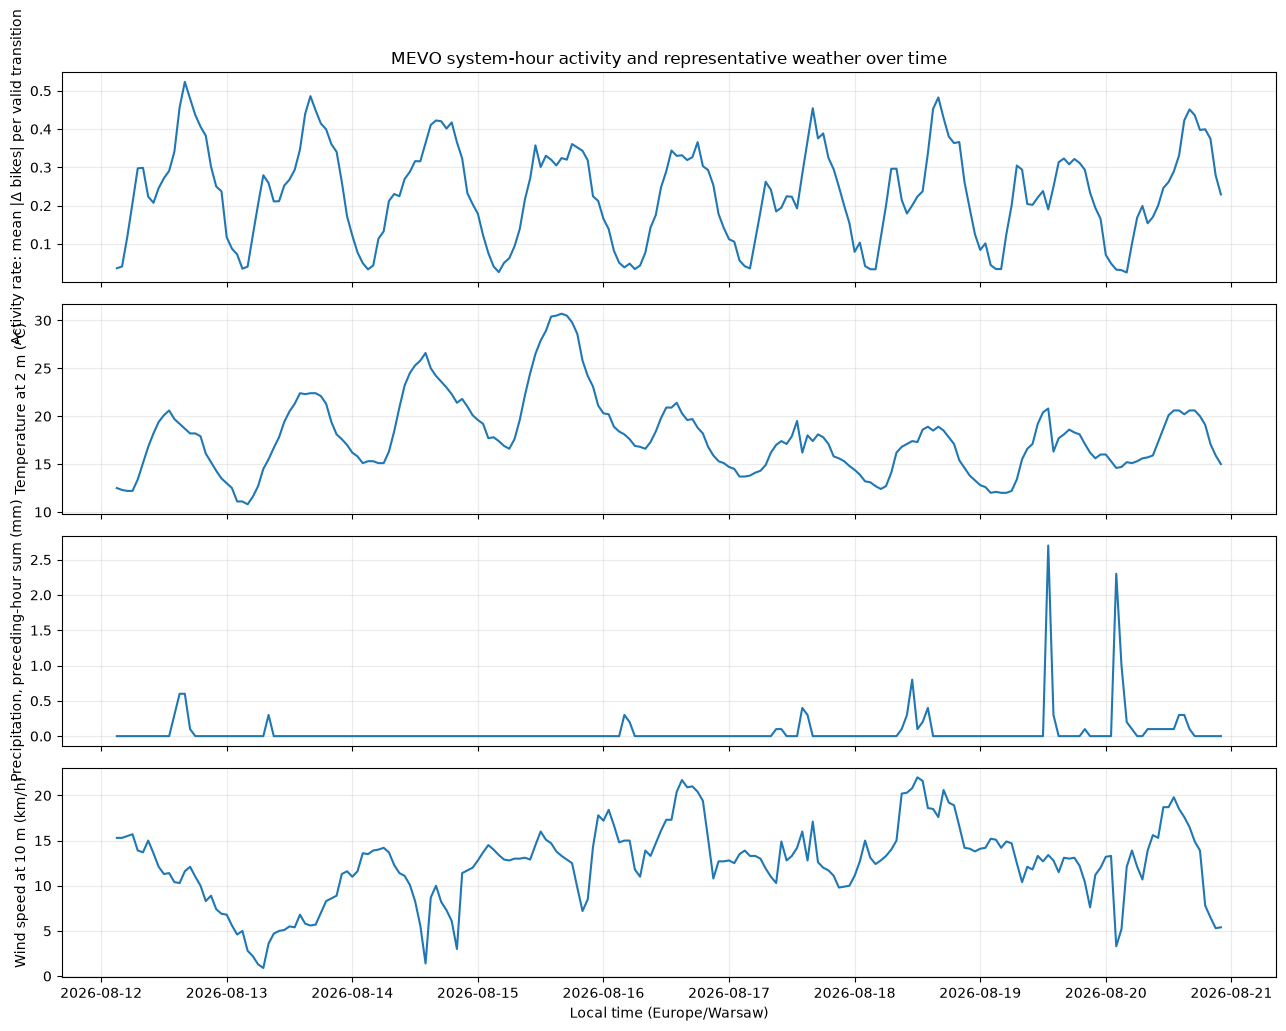

In [15]:
def plot_weather_time_series(frame: pd.DataFrame) -> None:
    plots = [
        ('activity_rate', 'Activity rate: mean |Δ bikes| per valid transition'),
        ('temperature_2m', 'Temperature at 2 m (°C)'),
        ('precipitation', 'Precipitation, preceding-hour sum (mm)'),
        ('wind_speed_10m', 'Wind speed at 10 m (km/h)'),
    ]
    fig, axes = plt.subplots(len(plots), 1, figsize=(13, 10), sharex=True)
    for axis, (column, label) in zip(axes, plots):
        axis.plot(frame['local_ts'], frame[column], linewidth=1.5)
        axis.set_ylabel(label)
        axis.grid(alpha=0.25)
    axes[0].set_title('MEVO system-hour activity and representative weather over time')
    axes[-1].set_xlabel('Local time (Europe/Warsaw)')
    fig.tight_layout()
    plt.show()


plot_weather_time_series(analysis_hourly)

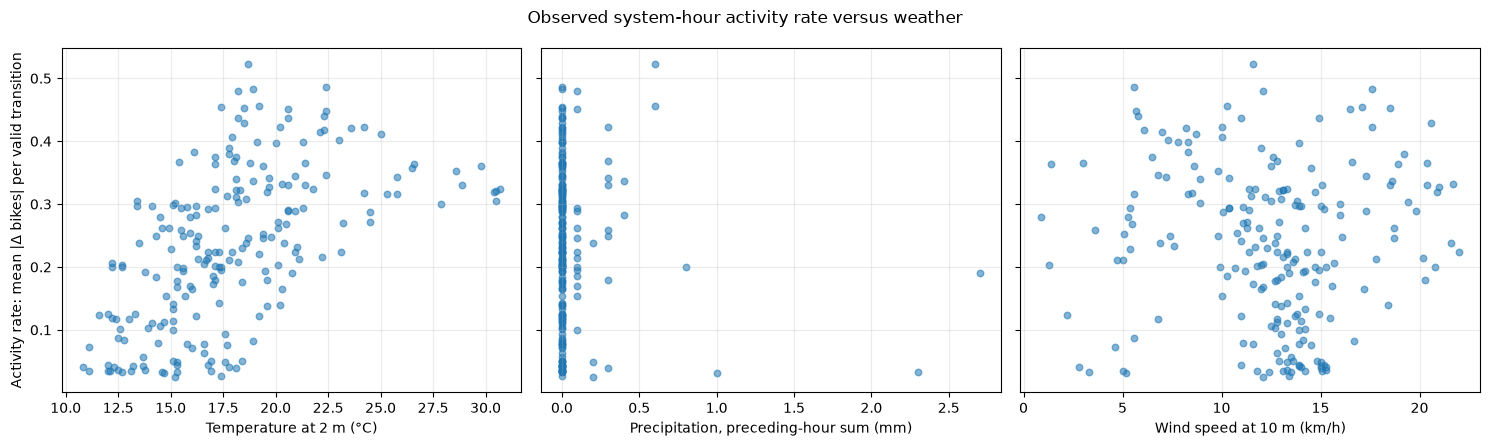

In [16]:
def plot_activity_weather_scatter(frame: pd.DataFrame) -> None:
    features = [
        ('temperature_2m', 'Temperature at 2 m (°C)'),
        ('precipitation', 'Precipitation, preceding-hour sum (mm)'),
        ('wind_speed_10m', 'Wind speed at 10 m (km/h)'),
    ]
    fig, axes = plt.subplots(1, len(features), figsize=(15, 4.5), sharey=True)
    for axis, (feature, label) in zip(axes, features):
        axis.scatter(frame[feature], frame['activity_rate'], alpha=0.55, s=22)
        axis.set_xlabel(label)
        axis.grid(alpha=0.25)
    axes[0].set_ylabel('Activity rate: mean |Δ bikes| per valid transition')
    fig.suptitle('Observed system-hour activity rate versus weather')
    fig.tight_layout()
    plt.show()


plot_activity_weather_scatter(analysis_hourly)

## Precipitation versus no precipitation analysis

Wet hours are defined transparently as has_precipitation = precipitation > 0, where precipitation is the Open-Meteo preceding-hour total precipitation sum in millimetres. The comparison reports wet/dry counts, means, medians, a simple Welch test, standardized effect size, and a calendar-day block-bootstrap confidence interval. The block-bootstrap CI is the primary uncertainty summary, effect size is more informative than p-value alone, and the Welch test is auxiliary. Resampling local dates rather than individual hours acknowledges within-day temporal dependence, while remaining intentionally simple.

In [17]:
def block_bootstrap_precipitation_difference(
    frame: pd.DataFrame,
    n_resamples: int = BOOTSTRAP_RESAMPLES,
    seed: int = BOOTSTRAP_RANDOM_SEED,
) -> tuple[float, float]:
    '''Return a 95% CI for mean wet minus dry activity using local-date blocks.'''
    sample = frame[['local_date', 'has_precipitation', 'activity_rate']].dropna().copy()
    dates = sample['local_date'].drop_duplicates().to_numpy()
    if len(dates) < 2:
        return np.nan, np.nan
    by_date = {date: group for date, group in sample.groupby('local_date', sort=False)}
    rng = np.random.default_rng(seed)
    estimates: list[float] = []
    for _ in range(n_resamples):
        sampled_dates = rng.choice(dates, size=len(dates), replace=True)
        sampled = pd.concat([by_date[date] for date in sampled_dates], ignore_index=True)
        wet = sampled.loc[sampled['has_precipitation'], 'activity_rate']
        dry = sampled.loc[~sampled['has_precipitation'], 'activity_rate']
        if len(wet) and len(dry):
            estimates.append(float(wet.mean() - dry.mean()))
    if not estimates:
        return np.nan, np.nan
    return tuple(np.quantile(estimates, [0.025, 0.975]))


def precipitation_comparison(frame: pd.DataFrame) -> pd.DataFrame:
    sample = frame[['local_date', 'has_precipitation', 'activity_rate']].dropna().copy()
    groups = sample.groupby('has_precipitation')['activity_rate']
    wet = groups.get_group(True) if True in groups.groups else pd.Series(dtype=float)
    dry = groups.get_group(False) if False in groups.groups else pd.Series(dtype=float)
    ci_low, ci_high = block_bootstrap_precipitation_difference(sample)
    if len(wet) >= 2 and len(dry) >= 2:
        test = stats.ttest_ind(wet, dry, equal_var=False, nan_policy='omit')
        pooled_variance = (
            (len(wet) - 1) * wet.var(ddof=1)
            + (len(dry) - 1) * dry.var(ddof=1)
        ) / (len(wet) + len(dry) - 2)
        pooled_sd = np.sqrt(pooled_variance)
        cohen_d = (wet.mean() - dry.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        p_value = test.pvalue
    else:
        cohen_d, p_value = np.nan, np.nan
    return pd.DataFrame([{
        'wet_hour_count': len(wet),
        'dry_hour_count': len(dry),
        'mean_activity_rate_wet': wet.mean(),
        'mean_activity_rate_dry': dry.mean(),
        'median_activity_rate_wet': wet.median(),
        'median_activity_rate_dry': dry.median(),
        'mean_difference_wet_minus_dry': wet.mean() - dry.mean(),
        'block_bootstrap_ci_95_low': ci_low,
        'block_bootstrap_ci_95_high': ci_high,
        'cohen_d_wet_minus_dry': cohen_d,
        'welch_test_p_value': p_value,
        'interpretation_note': 'Descriptive association only; hourly observations are temporally dependent.',
    }])


precipitation_results = precipitation_comparison(analysis_hourly)
display(precipitation_results)

,wet_hour_count,dry_hour_count,mean_activity_rate_wet,mean_activity_rate_dry,median_activity_rate_wet,median_activity_rate_dry,mean_difference_wet_minus_dry,block_bootstrap_ci_95_low,block_bootstrap_ci_95_high,cohen_d_wet_minus_dry,welch_test_p_value,interpretation_note
0,33,179,0.24298,0.231524,0.237446,0.233689,0.011456,-0.036844,0.095974,0.092127,0.649139,Descriptive association only; hourly observati...


## Temperature, wind, and temporal stratification

Temperature bins are deliberately broad and interpretable. Sparse bins remain visible through their support count and should not drive strong conclusions. The temporal summaries inspect weekday versus weekend, local hour, and broad daypart without creating a large set of sparse interactions.

In [18]:
TEMPERATURE_BIN_EDGES = [-np.inf, 0, 5, 10, 15, 20, 25, np.inf]
TEMPERATURE_BIN_LABELS = ['<0°C', '0–5°C', '5–10°C', '10–15°C', '15–20°C', '20–25°C', '≥25°C']


def temperature_bin_summary(frame: pd.DataFrame) -> pd.DataFrame:
    binned = frame.copy()
    binned['temperature_bin'] = pd.cut(
        binned['temperature_2m'],
        bins=TEMPERATURE_BIN_EDGES,
        labels=TEMPERATURE_BIN_LABELS,
        right=False,
    )
    return binned.groupby('temperature_bin', observed=False)['activity_rate'].agg(
        n='count', mean='mean', median='median', std='std'
    ).reset_index()


def temporal_activity_summaries(frame: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {
        'weekday_weekend': frame.groupby('is_weekend', dropna=False)['activity_rate'].agg(n='count', mean='mean', median='median').reset_index(),
        'local_hour': frame.groupby('local_hour', dropna=False)['activity_rate'].agg(n='count', mean='mean', median='median').reset_index(),
        'daypart': frame.groupby('daypart', dropna=False)['activity_rate'].agg(n='count', mean='mean', median='median').reset_index(),
        'wind_speed': frame[['wind_speed_10m', 'activity_rate']].describe().T.reset_index(names='metric'),
    }


temperature_summary = temperature_bin_summary(analysis_hourly)
temporal_summaries = temporal_activity_summaries(analysis_hourly)
display(temperature_summary)
display(temporal_summaries['weekday_weekend'])
display(temporal_summaries['local_hour'])
display(temporal_summaries['daypart'])

,temperature_bin,n,mean,median,std
0,<0°C,0,NaN,NaN,NaN
1,0–5°C,0,NaN,NaN,NaN
2,5–10°C,0,NaN,NaN,NaN
3,10–15°C,45,0.126416,0.110253,0.087505
4,15–20°C,112,0.231826,0.223971,0.120566
5,20–25°C,41,0.319219,0.318290,0.089601
6,≥25°C,14,0.337140,0.327296,0.029582


,is_weekend,n,mean,median
0,False,164,0.240200,0.237401
1,True,48,0.209759,0.220536


,local_hour,n,mean,median
0,0,8,0.116375,0.114858
1,1,8,0.098293,0.102436
2,2,8,0.057109,0.053217
3,3,9,0.037631,0.035245
4,4,9,0.035480,0.035827
5,5,9,0.100889,0.113681
6,6,9,0.154810,0.184086
7,7,9,0.220932,0.262272
8,8,9,0.221041,0.241291
9,9,9,0.199186,0.211071


,daypart,n,mean,median
0,afternoon,36,0.381424,0.365690
1,evening,53,0.297239,0.303246
2,midday,27,0.265216,0.261764
3,morning,45,0.201671,0.204231
4,night,51,0.073337,0.056611


## Pearson and Spearman associations

Correlations describe raw association, not causality. P-values are auxiliary only: hourly observations are time-dependent and can share temporal confounders. Raw wind_direction_10m is circular, so generic correlation analysis uses wind_direction_sin and wind_direction_cos; the raw degree field remains available for provenance, DQ, and descriptive display. The controlled regression baseline below is needed to assess incremental association after simple temporal controls; neither section measures forecasting performance.

In [19]:
CORRELATION_WEATHER_FEATURES = tuple(
    feature for feature in WEATHER_VARIABLES if feature != 'wind_direction_10m'
) + ('wind_direction_sin', 'wind_direction_cos')


def weather_associations(
    frame: pd.DataFrame,
    features: Iterable[str] = CORRELATION_WEATHER_FEATURES,
    outcome: str = 'activity_rate',
) -> pd.DataFrame:
    rows = []
    for feature in features:
        pair = frame[[feature, outcome]].dropna()
        if len(pair) >= 3 and pair[feature].nunique() > 1 and pair[outcome].nunique() > 1:
            pearson_r, pearson_p = stats.pearsonr(pair[feature], pair[outcome])
            spearman_rho, spearman_p = stats.spearmanr(pair[feature], pair[outcome])
        else:
            pearson_r = pearson_p = spearman_rho = spearman_p = np.nan
        rows.append({
            'feature': feature,
            'n': len(pair),
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_rho': spearman_rho,
            'spearman_p': spearman_p,
        })
    return pd.DataFrame(rows)


correlation_results = weather_associations(analysis_hourly)
display(correlation_results)

,feature,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,temperature_2m,212,0.563150,3.893434e-19,0.627626,1.275320e-24
1,precipitation,212,-0.056191,4.156670e-01,0.008461,9.025334e-01
2,wind_speed_10m,212,-0.038339,5.788072e-01,-0.093998,1.727047e-01
3,relative_humidity_2m,212,-0.512140,1.424028e-15,-0.540464,1.776864e-17
4,pressure_msl,212,0.118169,8.608546e-02,0.118754,8.453253e-02
5,sunshine_duration,212,0.593204,1.536313e-21,0.561582,5.118887e-19
6,wind_direction_sin,212,0.331246,8.034604e-07,0.169381,1.352948e-02
7,wind_direction_cos,212,0.226884,8.764319e-04,0.196091,4.155284e-03


## Statistical explanatory baseline

M0 is a temporal-only OLS baseline: activity_rate ~ C(local_hour) + C(day_of_week) + time_trend_days. M1 adds temperature_2m, precipitation, wind_speed_10m, and relative_humidity_2m. Pressure is held as an exploratory extended feature because it can be redundant with the core variables.

Both models use the same complete-case sample for a meaningful M0-to-M1 comparison. HAC robust standard errors with HAC_MAXLAGS = 24 are configured explicitly to reduce sensitivity to residual autocorrelation in this hourly statistical baseline. This is explanatory statistics, not ML or forecasting.

In [20]:
M0_FORMULA = 'activity_rate ~ C(local_hour) + C(day_of_week) + time_trend_days'
M1_FORMULA = M0_FORMULA + ' + temperature_2m + precipitation + wind_speed_10m + relative_humidity_2m'
M1_WEATHER_FEATURES = ('temperature_2m', 'precipitation', 'wind_speed_10m', 'relative_humidity_2m')


def require_statsmodels() -> None:
    if smf is None:
        raise ImportError(
            'statsmodels is required for the statistical explanatory baseline. '
            'Install it in the approved analytical environment before the final run; no installation is performed here.'
        )


def build_common_model_dataset(frame: pd.DataFrame) -> pd.DataFrame:
    required = [
        'activity_rate', 'local_hour', 'day_of_week', 'time_trend_days',
        'is_weekend', 'daypart',
        *M1_WEATHER_FEATURES,
    ]
    model_data = frame[required].dropna().copy()
    if len(model_data) < MIN_MODEL_OBSERVATIONS:
        raise RuntimeError(
            f'Only {len(model_data)} complete hourly observations are available; '
            f'at least {MIN_MODEL_OBSERVATIONS} are required for this baseline.'
        )
    return model_data


def fit_ols_hac(formula: str, model_data: pd.DataFrame):
    require_statsmodels()
    return smf.ols(formula=formula, data=model_data).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': HAC_MAXLAGS},
    )


def model_comparison_table(m0_result, m1_result) -> pd.DataFrame:
    values = {
        'n_obs': (m0_result.nobs, m1_result.nobs),
        'r_squared': (m0_result.rsquared, m1_result.rsquared),
        'adjusted_r_squared': (m0_result.rsquared_adj, m1_result.rsquared_adj),
        'aic': (m0_result.aic, m1_result.aic),
        'bic': (m0_result.bic, m1_result.bic),
    }
    rows = []
    for metric, (m0_value, m1_value) in values.items():
        rows.append({
            'metric': metric,
            'm0_temporal_only': m0_value,
            'm1_temporal_plus_weather': m1_value,
            'delta_m1_minus_m0': m1_value - m0_value,
        })
    return pd.DataFrame(rows)


def weather_coefficient_table(m1_result) -> pd.DataFrame:
    intervals = m1_result.conf_int()
    rows = []
    for feature in M1_WEATHER_FEATURES:
        rows.append({
            'feature': feature,
            'estimate': m1_result.params.get(feature, np.nan),
            'hac_standard_error': m1_result.bse.get(feature, np.nan),
            'ci_95_low': intervals.loc[feature, 0] if feature in intervals.index else np.nan,
            'ci_95_high': intervals.loc[feature, 1] if feature in intervals.index else np.nan,
            'p_value': m1_result.pvalues.get(feature, np.nan),
        })
    return pd.DataFrame(rows)

In [21]:
common_model_data = build_common_model_dataset(analysis_hourly)
m0_result = fit_ols_hac(M0_FORMULA, common_model_data)
m1_result = fit_ols_hac(M1_FORMULA, common_model_data)
model_comparison = model_comparison_table(m0_result, m1_result)
weather_coefficients = weather_coefficient_table(m1_result)
display(model_comparison)
display(weather_coefficients)

,metric,m0_temporal_only,m1_temporal_plus_weather,delta_m1_minus_m0
0,n_obs,212.000000,212.000000,0.000000
1,r_squared,0.894513,0.904986,0.010473
2,adjusted_r_squared,0.877028,0.886734,0.009706
3,aic,-698.854999,-713.022607,-14.167608
4,bic,-594.800824,-595.542087,-0.741263


,feature,estimate,hac_standard_error,ci_95_low,ci_95_high,p_value
0,temperature_2m,0.003726,0.001873,0.000055,0.007397,0.046681
1,precipitation,-0.015121,0.010812,-0.036312,0.006071,0.161961
2,wind_speed_10m,0.000499,0.001065,-0.001589,0.002587,0.639700
3,relative_humidity_2m,-0.001146,0.000635,-0.002390,0.000098,0.070994


## Limited interaction analysis

The optional interaction check is intentionally narrow. It adds three core weather interactions separately for weekday/weekend and broad daypart, on the same common sample, instead of building a high-dimensional station-level or all-hours interaction model. Interaction estimates are exploratory and require adequate support in every group.

In [22]:
INTERACTION_FEATURES = ('temperature_2m', 'precipitation', 'wind_speed_10m')


def interaction_support_summary(
    model_data: pd.DataFrame,
    minimum_group_observations: int = MIN_INTERACTION_GROUP_OBSERVATIONS,
) -> pd.DataFrame:
    rows = []
    for grouping, column in (
        ('weekday_weekend', 'is_weekend'),
        ('daypart', 'daypart'),
    ):
        counts = model_data.groupby(column, dropna=False).size()
        for group, count in counts.items():
            rows.append({
                'grouping': grouping,
                'group': str(group),
                'n_obs': int(count),
                'minimum_required': minimum_group_observations,
                'status': 'PASS' if count >= minimum_group_observations else 'WARN',
            })
    return pd.DataFrame(rows)


def fit_limited_interactions(
    analysis_frame: pd.DataFrame,
    model_data: pd.DataFrame,
    minimum_group_observations: int = MIN_INTERACTION_GROUP_OBSERVATIONS,
) -> pd.DataFrame:
    support = interaction_support_summary(model_data, minimum_group_observations)
    if support.empty or support['n_obs'].lt(minimum_group_observations).any():
        print('WARN: interaction support is below threshold; interaction models were skipped.')
        return pd.DataFrame(columns=['analysis', 'term', 'estimate', 'hac_standard_error', 'ci_95_low', 'ci_95_high', 'p_value', 'n_obs'])
    base = M1_FORMULA
    formulas = {
        'weather_by_weekday_weekend': base + ' + ' + ' + '.join(
            f'{feature}:C(is_weekend)' for feature in INTERACTION_FEATURES
        ),
        'weather_by_daypart': base + ' + ' + ' + '.join(
            f'{feature}:C(daypart)' for feature in INTERACTION_FEATURES
        ),
    }
    interaction_data = analysis_frame.loc[model_data.index].copy()
    rows = []
    for analysis_name, formula in formulas.items():
        result = fit_ols_hac(formula, interaction_data)
        intervals = result.conf_int()
        for term in result.params.index:
            if ':' in term:
                rows.append({
                    'analysis': analysis_name,
                    'term': term,
                    'estimate': result.params[term],
                    'hac_standard_error': result.bse[term],
                    'ci_95_low': intervals.loc[term, 0],
                    'ci_95_high': intervals.loc[term, 1],
                    'p_value': result.pvalues[term],
                    'n_obs': result.nobs,
                })
    return pd.DataFrame(rows)


interaction_support = interaction_support_summary(common_model_data)
display(interaction_support)
interaction_results = fit_limited_interactions(analysis_hourly, common_model_data)
display(interaction_results)

,grouping,group,n_obs,minimum_required,status
0,weekday_weekend,False,164,24,PASS
1,weekday_weekend,True,48,24,PASS
2,daypart,afternoon,36,24,PASS
3,daypart,evening,53,24,PASS
4,daypart,midday,27,24,PASS
5,daypart,morning,45,24,PASS
6,daypart,night,51,24,PASS


,analysis,term,estimate,hac_standard_error,ci_95_low,ci_95_high,p_value,n_obs
0,weather_by_weekday_weekend,temperature_2m:C(is_weekend)[T.True],-0.000419,0.002310,-0.004947,0.004110,8.561352e-01,212.0
1,weather_by_weekday_weekend,precipitation:C(is_weekend)[T.True],0.055892,0.044244,-0.030825,0.142608,2.064960e-01,212.0
2,weather_by_weekday_weekend,wind_speed_10m:C(is_weekend)[T.True],0.005983,0.003439,-0.000758,0.012724,8.194062e-02,212.0
3,weather_by_daypart,temperature_2m:C(daypart)[T.evening],0.005646,0.002893,-0.000023,0.011316,5.094479e-02,212.0
4,weather_by_daypart,temperature_2m:C(daypart)[T.midday],0.015245,0.002738,0.009878,0.020612,2.590357e-08,212.0
5,weather_by_daypart,temperature_2m:C(daypart)[T.morning],-0.001006,0.005637,-0.012054,0.010043,8.584285e-01,212.0
6,weather_by_daypart,temperature_2m:C(daypart)[T.night],0.011719,0.004569,0.002765,0.020674,1.031611e-02,212.0
7,weather_by_daypart,precipitation:C(daypart)[T.evening],-0.424330,0.148000,-0.714404,-0.134256,4.142525e-03,212.0
8,weather_by_daypart,precipitation:C(daypart)[T.midday],-0.092501,0.047341,-0.185287,0.000285,5.070905e-02,212.0
9,weather_by_daypart,precipitation:C(daypart)[T.morning],-0.190106,0.101077,-0.388213,0.008002,5.999900e-02,212.0


## Station sensitivity

Station-level weather sensitivity is deferred until longer history and or regional weather enrichment are available. One common weather point means that treating hundreds of stations in the same hour as independent weather exposures would create pseudoreplication.

## KEEP / MAYBE / DROP feature-selection framework

The table below intentionally has no final decisions before the controlled approximately 30-day execution. After review, decision must be one of KEEP, MAYBE, or DROP. It must weigh DQ, availability, variation, domain plausibility, effect size, raw and controlled association, M0-to-M1 incremental information, redundancy, inference availability, and the short history. DROP means not justified for the current production feature layer based on available evidence, not that a variable can never matter.

The preliminary_evidence_summary below is a compact evidence extract for this integration run. It can guide future feature-layer design, but final KEEP/MAYBE/DROP decisions are deferred to the controlled approximately 30-day rerun.

In [23]:
FEATURE_DECISION_ROWS = [
    ('temperature', 'temperature_2m'),
    ('precipitation', 'precipitation'),
    ('wind_speed', 'wind_speed_10m'),
    ('relative_humidity', 'relative_humidity_2m'),
    ('pressure', 'pressure_msl'),
    ('wind_direction', 'wind_direction_10m'),
    ('sunshine_duration', 'sunshine_duration'),
]


def initialise_feature_decision_framework() -> pd.DataFrame:
    return pd.DataFrame([
        {
            'feature': label,
            'source_column': column,
            'data_quality': pd.NA,
            'variation_in_window': pd.NA,
            'raw_association': pd.NA,
            'controlled_association': pd.NA,
            'incremental_value': pd.NA,
            'redundancy_notes': pd.NA,
            'inference_availability_notes': (
                'Retrospective preceding-hour value; future use needs lagged known data or a forecast representation.'
                if label in {'precipitation', 'sunshine_duration'}
                else 'Assess availability at prediction time before any future forecasting use.'
            ),
            'decision': pd.NA,
            'rationale': (
                'Populate after the frozen-window DQ and statistical review; use circular sin/cos '
                'representation rather than raw degrees for wind_direction.'
                if label == 'wind_direction'
                else 'Populate after the frozen-window DQ and statistical review.'
            ),
        }
        for label, column in FEATURE_DECISION_ROWS
    ])


feature_decision_framework = initialise_feature_decision_framework()
display(feature_decision_framework)


def build_preliminary_evidence_summary(
    frame: pd.DataFrame,
    associations: pd.DataFrame,
    coefficients: pd.DataFrame,
    weather_quality: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    for label, column in FEATURE_DECISION_ROWS:
        values = frame[column].dropna()
        quality_match = weather_quality.loc[weather_quality['metric'].eq(f'missing_{column}'), 'status']
        dq_status = quality_match.iloc[0] if not quality_match.empty else 'WARN'
        association_features = (
            ('wind_direction_sin', 'wind_direction_cos')
            if column == 'wind_direction_10m' else (column,)
        )
        raw_parts = []
        for association_feature in association_features:
            match = associations.loc[associations['feature'].eq(association_feature)]
            if not match.empty:
                raw_parts.append(
                    f'{association_feature}: Pearson r={match.iloc[0]["pearson_r"]:.3f}, '
                    f'Spearman rho={match.iloc[0]["spearman_rho"]:.3f}'
                )
        controlled_match = coefficients.loc[coefficients['feature'].eq(column), 'estimate']
        controlled_p = coefficients.loc[coefficients['feature'].eq(column), 'p_value']
        rows.append({
            'feature': label,
            'source_column': column,
            'data_quality': dq_status,
            'n_available': len(values),
            'non_null_rate': len(values) / len(frame) if len(frame) else np.nan,
            'observed_std': values.std(ddof=1),
            'raw_association': '; '.join(raw_parts) if raw_parts else 'not estimable',
            'controlled_estimate': controlled_match.iloc[0] if not controlled_match.empty else np.nan,
            'controlled_p_value': controlled_p.iloc[0] if not controlled_p.empty else np.nan,
            'inference_availability_notes': (
                'Retrospective preceding-hour value; future representation must be chosen explicitly.'
                if label in {'precipitation', 'sunshine_duration'}
                else 'Final availability review remains pending.'
            ),
            'evidence_note': 'Preliminary short-window evidence; final decision deferred.',
        })
    return pd.DataFrame(rows)


preliminary_evidence_summary = build_preliminary_evidence_summary(
    analysis_hourly,
    correlation_results,
    weather_coefficients,
    weather_dq,
)
display(preliminary_evidence_summary)

,feature,source_column,data_quality,variation_in_window,raw_association,controlled_association,incremental_value,redundancy_notes,inference_availability_notes,decision,rationale
0,temperature,temperature_2m,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Assess availability at prediction time before ...,<NA>,Populate after the frozen-window DQ and statis...
1,precipitation,precipitation,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Retrospective preceding-hour value; future use...,<NA>,Populate after the frozen-window DQ and statis...
2,wind_speed,wind_speed_10m,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Assess availability at prediction time before ...,<NA>,Populate after the frozen-window DQ and statis...
3,relative_humidity,relative_humidity_2m,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Assess availability at prediction time before ...,<NA>,Populate after the frozen-window DQ and statis...
4,pressure,pressure_msl,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Assess availability at prediction time before ...,<NA>,Populate after the frozen-window DQ and statis...
5,wind_direction,wind_direction_10m,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Assess availability at prediction time before ...,<NA>,Populate after the frozen-window DQ and statis...
6,sunshine_duration,sunshine_duration,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Retrospective preceding-hour value; future use...,<NA>,Populate after the frozen-window DQ and statis...


,feature,source_column,data_quality,n_available,non_null_rate,observed_std,raw_association,controlled_estimate,controlled_p_value,inference_availability_notes,evidence_note
0,temperature,temperature_2m,PASS,212,1.0,4.039274,"temperature_2m: Pearson r=0.563, Spearman rho=...",0.003726,0.046681,Final availability review remains pending.,Preliminary short-window evidence; final decis...
1,precipitation,precipitation,PASS,212,1.0,0.270318,"precipitation: Pearson r=-0.056, Spearman rho=...",-0.015121,0.161961,Retrospective preceding-hour value; future rep...,Preliminary short-window evidence; final decis...
2,wind_speed,wind_speed_10m,PASS,212,1.0,4.278951,"wind_speed_10m: Pearson r=-0.038, Spearman rho...",0.000499,0.639700,Final availability review remains pending.,Preliminary short-window evidence; final decis...
3,relative_humidity,relative_humidity_2m,PASS,212,1.0,16.298565,"relative_humidity_2m: Pearson r=-0.512, Spearm...",-0.001146,0.070994,Final availability review remains pending.,Preliminary short-window evidence; final decis...
4,pressure,pressure_msl,PASS,212,1.0,9.478148,"pressure_msl: Pearson r=0.118, Spearman rho=0.119",NaN,NaN,Final availability review remains pending.,Preliminary short-window evidence; final decis...
5,wind_direction,wind_direction_10m,PASS,212,1.0,53.114758,"wind_direction_sin: Pearson r=0.331, Spearman ...",NaN,NaN,Final availability review remains pending.,Preliminary short-window evidence; final decis...
6,sunshine_duration,sunshine_duration,PASS,212,1.0,1728.859808,"sunshine_duration: Pearson r=0.593, Spearman r...",NaN,NaN,Retrospective preceding-hour value; future rep...,Preliminary short-window evidence; final decis...


## Statistical limitations

1. This is observational analysis; correlation and regression do not establish causality.
2. MEVO history is short; approximately 30 days is not sufficient for seasonal conclusions.
3. Weather variation and precipitation observations may be limited in the frozen window.
4. activity_proxy is not ground-truth demand and can be affected by rebalancing and service operations.
5. Weather comes from one representative point for the whole Trójmiasto network, not local station measurements.
6. Open-Meteo model data are gridded model or reanalysis information, not ground-truth station weather measurements.
7. Hourly observations are autocorrelated; HAC standard errors reduce but do not eliminate this limitation.
8. The Sprint 3 result is a methodological and statistical baseline, not a forecasting evaluation.
9. Results should be described as associated with, consistent with, observed relationship, or incremental statistical signal rather than weather causes an outcome.

## Preliminary Sprint 3 findings

The preliminary analysis covers 212 complete system-hours from 2026-08-12 01:00 UTC to 2026-08-20 21:00 UTC. MEVO and weather coverage matched one-to-one for all 212 hours: expected hours = 212, MEVO hours = 212, weather hours = 212, joined hours = 212, and join match rate = 1.0. There were no duplicate hour keys, no missing expected hours, and no missing core weather variables after UTC alignment.

System activity shows a strong temporal structure. The temporal-only baseline (M0) achieved an adjusted R² of approximately 0.877, indicating that hour-of-day, day-of-week, and the short-term time trend explain most of the observed variation in activity_rate. Adding temperature, precipitation, wind speed, and relative humidity increased adjusted R² to approximately 0.887, an increment of about 0.010. Weather therefore adds some incremental statistical information within this window, but the gain is modest relative to the temporal structure.

Temperature showed the clearest preliminary weather signal. Its raw association with activity_rate was moderately positive (Pearson r ≈ 0.563; Spearman rho ≈ 0.628), and its HAC-robust M1 coefficient remained positive (estimate ≈ +0.00373; 95% CI ≈ [0.00006, 0.00740]; p ≈ 0.0467) after temporal controls. This remains an observed relationship and should not be interpreted causally. Relative humidity showed a weaker possible controlled association (p ≈ 0.071). Precipitation and wind speed did not show a clear independent signal in this short sample (controlled p ≈ 0.162 and p ≈ 0.640, respectively).

Precipitation evidence is especially uncertain: 33 of 212 hours were wet and 179 were dry. Mean activity_rate was approximately 0.243 for wet hours and 0.232 for dry hours. These descriptive differences should not be generalized beyond the preliminary window.

Temperature-bin summaries are interpretable only over the observed range. The counts were n = 0 for <0°C, 0 for 0–5°C, 0 for 5–10°C, 45 for 10–15°C, 112 for 15–20°C, 41 for 20–25°C, and 14 for ≥25°C. Approximate activity_rate means were 0.126, 0.232, 0.319, and 0.337 for the non-empty 10–15°C, 15–20°C, 20–25°C, and ≥25°C bins. Empty bins below 10°C reflect no observations in those ranges, not missing or invalid data.

These findings are observational, non-causal, and based on a short summer-only historical window; they do not support seasonal conclusions. Raw weather associations are confounded by temporal structure, and activity_proxy represents observed absolute station-level changes in bike availability, not ride count or ground-truth demand. This run validates the Sprint 3 methodology and provides early feature-selection evidence, but final KEEP / MAYBE / DROP decisions remain deferred until the controlled approximately 30-day rerun.

## Preliminary Run All checklist

1. Verify the saved Sprint 2 period summaries and the configured preliminary full-hour subwindow.
2. Confirm the project kernel and analytical dependencies.
3. Set FINAL_ANALYSIS_ENABLED = True (already set for this preliminary run).
4. Execute this notebook manually with Run All.
5. Review MEVO, coordinate, weather, and join DQ.
6. Verify Open-Meteo provenance, units, model grid point, and timestamp semantics.
7. Review preliminary descriptive statistics, correlations, precipitation comparison, and M0/M1 output.
8. Treat all findings as preliminary evidence; do not finalize KEEP / MAYBE / DROP.

## Final approximately 30-day rerun checklist

1. Wait for approximately 30 days of MEVO history.
2. Before rerunning, freeze one explicit common UTC analysis window for notebooks 01–04; dynamic MIN/MAX behaviour in Sprint 2 must not produce different periods if new CLEANED partitions arrive between executions.
3. Rerun 01_data_quality_and_baseline.ipynb, then 02_eda.ipynb, then 03_feature_engineering.ipynb.
4. Confirm the exact shared analysis_start_utc and analysis_end_utc.
5. Set the same UTC bounds in this notebook and change ANALYSIS_MODE to 'final'.
6. Execute this notebook and review all DQ, timestamp, join, and statistical checks.
7. Populate KEEP / MAYBE / DROP decisions manually from the final evidence.
8. Only then save final, correctly computed notebook outputs.

In [24]:
# Static review helper: no external load is performed by this cell.
SYSTEM_HOUR_SQL_TEMPLATE = build_system_hour_sql(
    pd.Timestamp('2026-01-01 00:00:00', tz='UTC'),
    pd.Timestamp('2026-01-02 00:00:00', tz='UTC'),
)
forbidden_write_phrases = ('INSERT INTO', 'CREATE TABLE', 'CREATE VIEW', 'UNLOAD')
assert not any(phrase in SYSTEM_HOUR_SQL_TEMPLATE.upper() for phrase in forbidden_write_phrases)
assert 'LAG(' in SYSTEM_HOUR_SQL_TEMPLATE.upper()
assert 'BETWEEN 7 AND 13' in SYSTEM_HOUR_SQL_TEMPLATE
assert 'ABS(DELTA_BIKES)' in SYSTEM_HOUR_SQL_TEMPLATE.upper()
assert 'SNAPSHOT_TS >=' in SYSTEM_HOUR_SQL_TEMPLATE.upper()
assert 'SNAPSHOT_TS <' in SYSTEM_HOUR_SQL_TEMPLATE.upper()
print('Static SQL review passed; no Athena or Open-Meteo request was executed.')

Static SQL review passed; no Athena or Open-Meteo request was executed.
